# Image Classification Pipeline

This notebook follows the logic in `project.py` and turns it into an exploratory workflow.

It covers:
- the class-wise split used by the project
- a visual check of the dataset
- the descriptor set used for classification
- per-descriptor and fused evaluation results

The implementation reuses the functions from `project.py`, so the notebook stays aligned with the script version.

In [38]:
from collections import Counter
import importlib

import matplotlib.pyplot as plt
import numpy as np

import project as project_module
project = importlib.reload(project_module)

from project import (
    accuracy_score,
    apply_standardization,
    build_bovw_codebook,
    combine_feature_blocks,
    extract_bundles,
    load_pet_records,
    load_rgb_image,
    matrix_from_bundles,
    predict_nearest_centroid,
    standardize_features,
    split_pets_by_class,
    train_nearest_centroid,
)

# Manual tuning knobs you can change and rerun.
HARALICK_LEVELS = 32
LBP_POINTS = 8
LBP_RADIUS_R1 = 1
LBP_RADIUS_R2 = 2
HOG_BINS = 8
BOVW_REGION_SIZE = 32
BOVW_CLUSTER_CANDIDATES = [4, 8, 12, 16]
BOVW_POINTS = 8
BOVW_RADIUS = 1
GABOR_FREQUENCIES = (0.08, 0.16)
GABOR_ORIENTATIONS = (0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4)
GABOR_SIGMA = 4.0
GABOR_GAMMA = 0.5
HSV_BINS = 6

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Load and split the dataset

The script uses a class-wise split: images are grouped by `class_name`, shuffled, and then split into train, validation, and test sets.

Classes with fewer than 3 images are skipped because they cannot support the split reliably.

In [39]:
records = load_pet_records('pets.csv')
train_records, test_records, validation_records, skipped_classes = split_pets_by_class(records)

print(f'Loaded {len(records)} images')
print(f'Train split: {len(train_records)} images')
print(f'Validation split: {len(validation_records)} images')
print(f'Test split: {len(test_records)} images')
print(f'Skipped classes: {len(skipped_classes)}')

Loaded 367 images
Train split: 268 images
Validation split: 47 images
Test split: 47 images
Skipped classes: 5


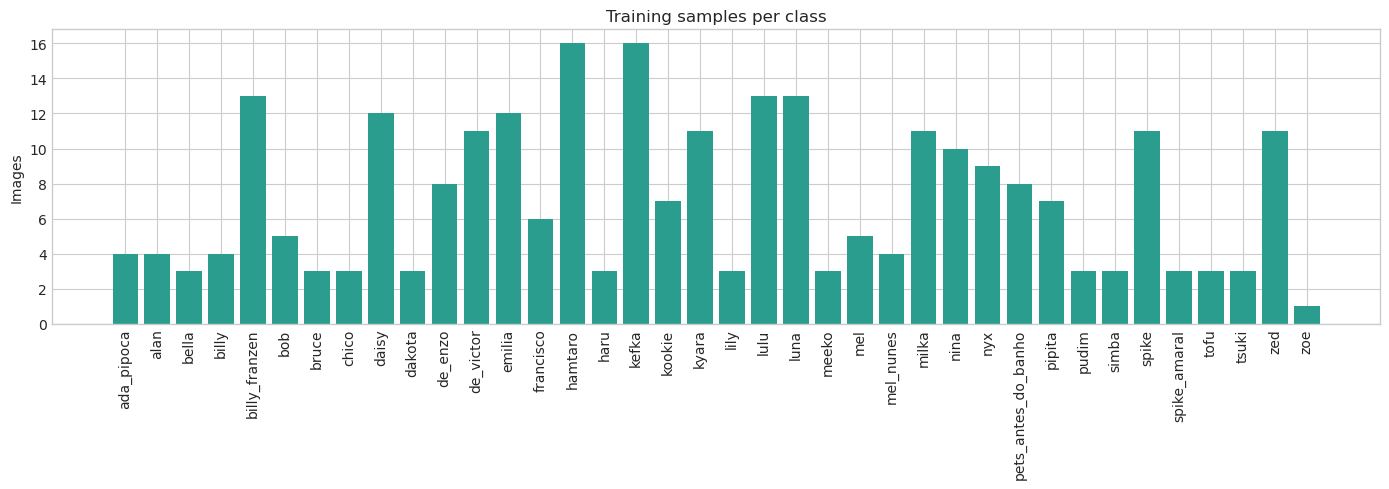

In [40]:
# Visualize how many samples each class contributes to the training split.
train_counts = Counter(record.class_name for record in train_records)
classes = sorted(train_counts)
counts = [train_counts[class_name] for class_name in classes]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(classes, counts, color='#2a9d8f')
ax.set_title('Training samples per class')
ax.set_ylabel('Images')
ax.tick_params(axis='x', rotation=90)
fig.tight_layout()

## 2. Inspect a few images

A quick visual check is useful before feature extraction. The descriptors are sensitive to texture, color, and edge patterns, so it helps to confirm the dataset looks reasonable.

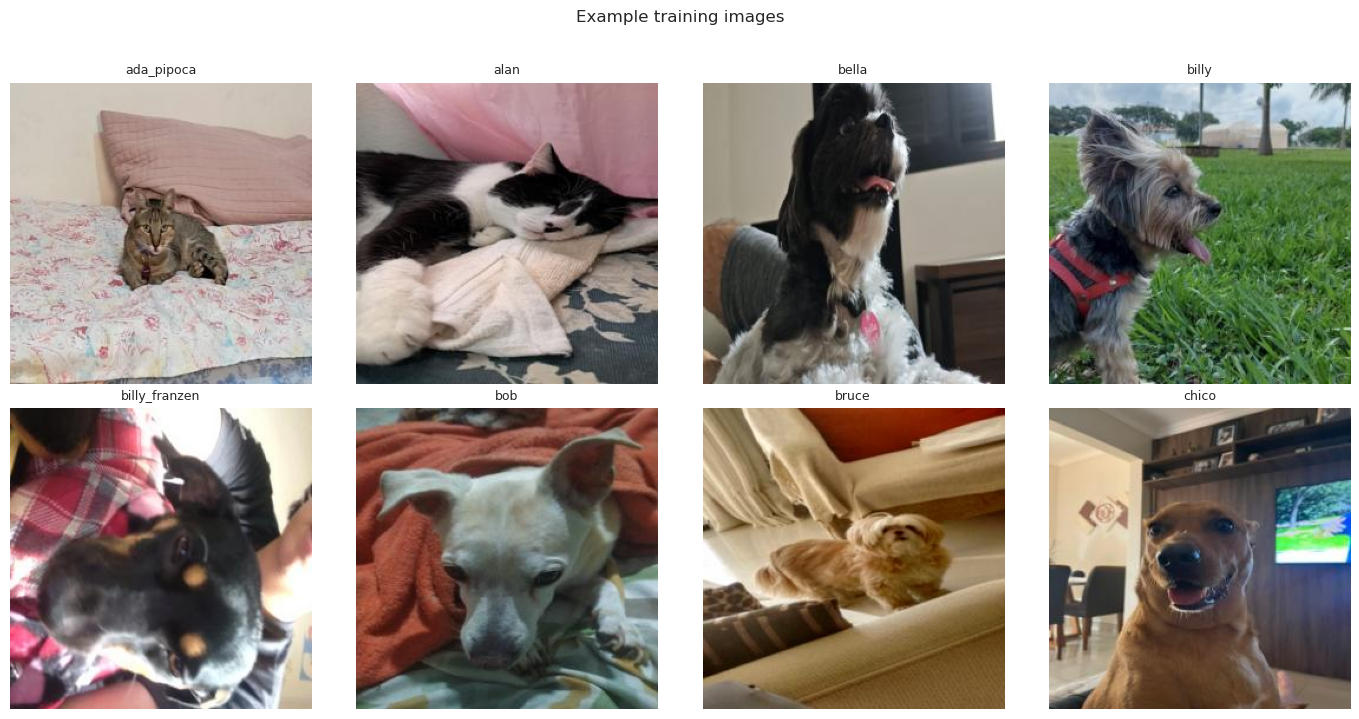

In [41]:
# Show a small grid of training images from different classes.
sample_records = []
seen_classes = set()
for record in train_records:
    if record.class_name not in seen_classes:
        sample_records.append(record)
        seen_classes.add(record.class_name)
    if len(sample_records) == 8:
        break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, record in zip(axes.flat, sample_records):
    image = load_rgb_image(record.path)
    ax.imshow(image)
    ax.set_title(record.class_name, fontsize=9)
    ax.axis('off')

for ax in axes.flat[len(sample_records):]:
    ax.axis('off')

fig.suptitle('Example training images', y=1.02)
fig.tight_layout()

## 3. Use a richer descriptor set

The earlier lightweight version removed BoVW, but that descriptor is useful here because it captures recurring local texture patterns at a higher level than plain histograms.

The current mix keeps the compact descriptors and adds BoVW back, plus two more strong cues:
- Haralick texture statistics
- Local Binary Patterns at two radii
- Histogram of Oriented Gradients
- Bag of Visual Words built from regional LBP patches
- Color moments in Lab space
- Gabor texture responses
- HSV color histograms

You can tune the codebook size, region size, and the texture/color parameters in the import cell above.

This gives the model both low-level and mid-level cues without changing the classifier.

In [42]:
descriptor_message = (
    'Descriptor set: Haralick, LBP r=1, LBP r=2, HOG, BoVW, color moments, Gabor, and HSV histograms.'
)
print(descriptor_message)

Descriptor set: Haralick, LBP r=1, LBP r=2, HOG, BoVW, color moments, Gabor, and HSV histograms.


## 4. Extract descriptor bundles

Each image is converted into eight feature vectors:
- Haralick texture statistics
- Local Binary Patterns with radius 1
- Local Binary Patterns with radius 2
- Histogram of Oriented Gradients
- Bag of Visual Words from regional LBP patches
- Color moments in Lab space
- Gabor texture responses
- HSV color histograms

The notebook keeps these descriptors separate first, then also evaluates a fused feature vector at the end.

In [ ]:
bovw_runs = []
best_bovw = None

for cluster_count in BOVW_CLUSTER_CANDIDATES:
    bovw_codebook = build_bovw_codebook(
        train_records,
        region_size=BOVW_REGION_SIZE,
        clusters=cluster_count,
        points=BOVW_POINTS,
        radius=BOVW_RADIUS,
    )
    print(f'BoVW codebook size ({cluster_count} clusters): {len(bovw_codebook)}')

    train_labels, train_bundles = extract_bundles(
        train_records,
        bovw_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    validation_labels, validation_bundles = extract_bundles(
        validation_records,
        bovw_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    test_labels, test_bundles = extract_bundles(
        test_records,
        bovw_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )

    train_matrix = matrix_from_bundles(train_bundles, 'bovw')
    validation_matrix = matrix_from_bundles(validation_bundles, 'bovw')
    test_matrix = matrix_from_bundles(test_bundles, 'bovw')

    train_scaled, mean, std = standardize_features(train_matrix)
    validation_scaled = apply_standardization(validation_matrix, mean, std)
    test_scaled = apply_standardization(test_matrix, mean, std)

    centroids = train_nearest_centroid(train_scaled, train_labels)
    validation_score = accuracy_score(validation_labels, predict_nearest_centroid(validation_scaled, centroids))
    test_score = accuracy_score(test_labels, predict_nearest_centroid(test_scaled, centroids))

    bovw_runs.append({
        'clusters': cluster_count,
        'codebook': bovw_codebook,
        'train_labels': train_labels,
        'train_bundles': train_bundles,
        'validation_labels': validation_labels,
        'validation_bundles': validation_bundles,
        'test_labels': test_labels,
        'test_bundles': test_bundles,
        'validation_score': validation_score,
        'test_score': test_score,
    })

    if best_bovw is None or validation_score > best_bovw['validation_score']:
        best_bovw = bovw_runs[-1]

assert best_bovw is not None
print(f"Best BoVW clusters by validation: {best_bovw['clusters']}")
print(f"Best BoVW validation accuracy: {best_bovw['validation_score']:.3f}")
print(f"Best BoVW test accuracy: {best_bovw['test_score']:.3f}")

bovw_codebook = best_bovw['codebook']
train_labels = best_bovw['train_labels']
train_bundles = best_bovw['train_bundles']
validation_labels = best_bovw['validation_labels']
validation_bundles = best_bovw['validation_bundles']
test_labels = best_bovw['test_labels']
test_bundles = best_bovw['test_bundles']

descriptor_names = ['haralick', 'lbp_r1', 'lbp_r2', 'hog', 'bovw', 'color_moments', 'gabor', 'hsv_histogram']
descriptor_labels = {
    'haralick': 'Haralick',
    'lbp_r1': 'LBP r=1',
    'lbp_r2': 'LBP r=2',
    'hog': 'HOG',
    'bovw': 'BoVW',
    'color_moments': 'Color moments',
    'gabor': 'Gabor',
    'hsv_histogram': 'HSV hist',
}

def evaluate_descriptor_bundle(descriptor_name: str):
    train_matrix = matrix_from_bundles(train_bundles, descriptor_name)
    validation_matrix = matrix_from_bundles(validation_bundles, descriptor_name)
    test_matrix = matrix_from_bundles(test_bundles, descriptor_name)

    train_scaled, mean, std = standardize_features(train_matrix)
    validation_scaled = apply_standardization(validation_matrix, mean, std)
    test_scaled = apply_standardization(test_matrix, mean, std)

    centroids = train_nearest_centroid(train_scaled, train_labels)
    validation_score = accuracy_score(validation_labels, predict_nearest_centroid(validation_scaled, centroids))
    test_score = accuracy_score(test_labels, predict_nearest_centroid(test_scaled, centroids))
    return train_scaled, validation_scaled, test_scaled, validation_score, test_score

results = {}
scaled_blocks = {'train': [], 'validation': [], 'test': []}

for descriptor_name in descriptor_names:
    train_scaled, validation_scaled, test_scaled, validation_score, test_score = evaluate_descriptor_bundle(descriptor_name)
    results[descriptor_labels[descriptor_name]] = {
        'validation': validation_score,
        'test': test_score,
    }
    scaled_blocks['train'].append(train_scaled)
    scaled_blocks['validation'].append(validation_scaled)
    scaled_blocks['test'].append(test_scaled)

results

BoVW codebook size (4 clusters): 4
BoVW codebook size (8 clusters): 8
BoVW codebook size (12 clusters): 12
BoVW codebook size (16 clusters): 16
Best BoVW clusters by validation: 8
Best BoVW validation accuracy: 0.085
Best BoVW test accuracy: 0.128


{'Haralick': {'test': 0.06382978723404255, 'validation': 0.0425531914893617},
 'LBP r=1': {'test': 0.1276595744680851, 'validation': 0.14893617021276595},
 'LBP r=2': {'test': 0.10638297872340426, 'validation': 0.0425531914893617},
 'HOG': {'test': 0.1702127659574468, 'validation': 0.0425531914893617},
 'BoVW': {'test': 0.1276595744680851, 'validation': 0.0851063829787234},
 'Color moments': {'test': 0.1276595744680851,
  'validation': 0.10638297872340426},
 'Gabor': {'test': 0.2127659574468085, 'validation': 0.0851063829787234},
 'HSV hist': {'test': 0.1276595744680851, 'validation': 0.14893617021276595}}

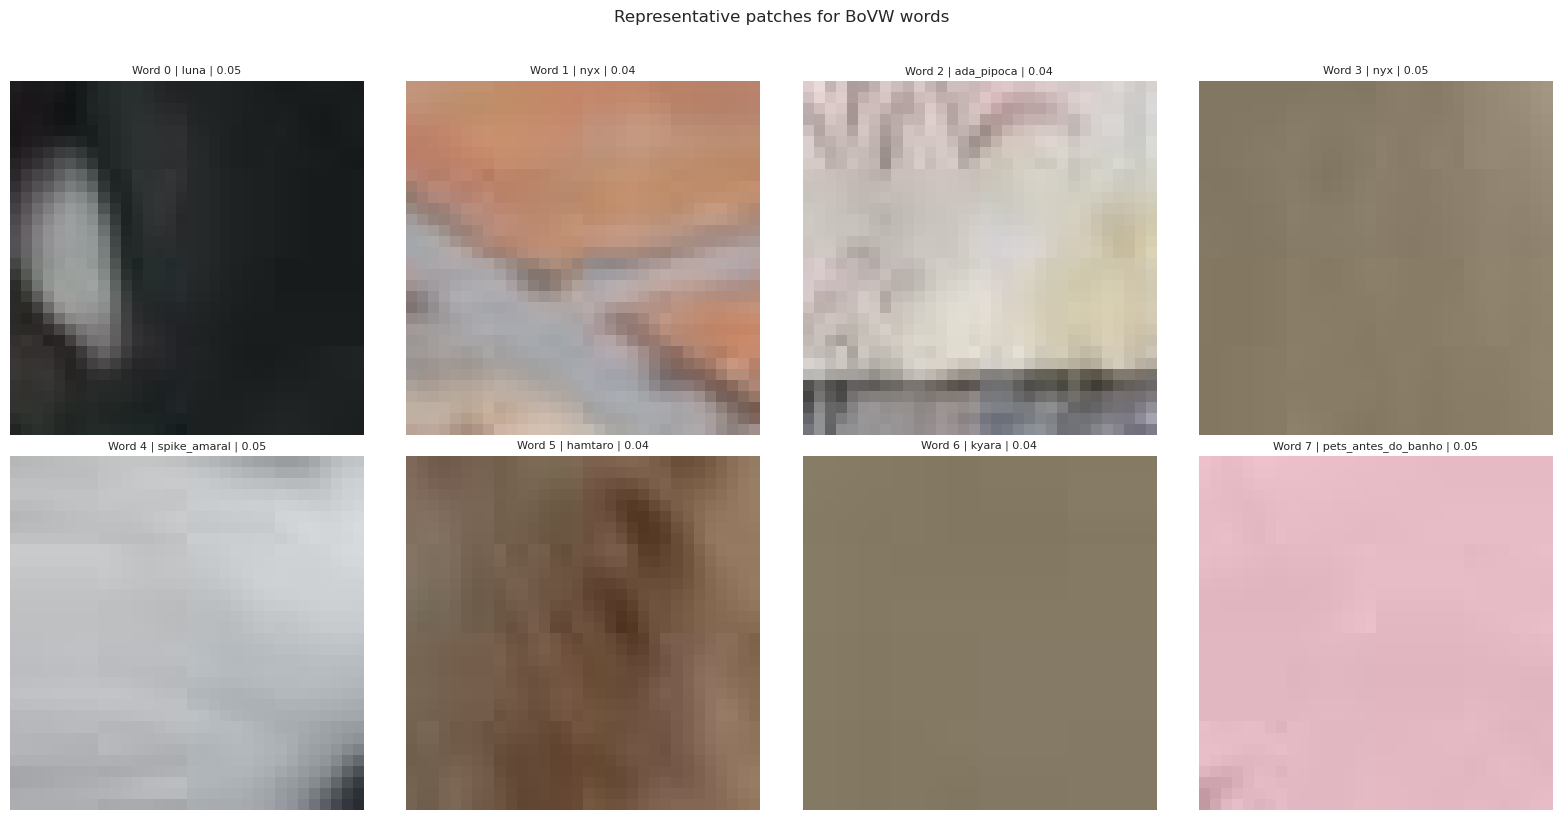

In [44]:
def iter_bovw_patches(image, region_size):
    height, width = image.shape[:2]
    for row_start in range(0, height, region_size):
        for col_start in range(0, width, region_size):
            patch = image[row_start:row_start + region_size, col_start:col_start + region_size]
            if patch.size == 0:
                continue
            yield patch, project.lbp_features(patch, points=BOVW_POINTS, radius=BOVW_RADIUS)

best_words = [None] * len(bovw_codebook)
for record in train_records:
    image = load_rgb_image(record.path)
    for patch, feature in iter_bovw_patches(image, BOVW_REGION_SIZE):
        if feature.size != bovw_codebook.shape[1]:
            continue
        distances = np.linalg.norm(bovw_codebook - feature, axis=1)
        word_index = int(np.argmin(distances))
        score = float(distances[word_index])
        current = best_words[word_index]
        if current is None or score < current[0]:
            best_words[word_index] = (score, patch, record.class_name)

columns = min(4, len(best_words))
rows = int(np.ceil(len(best_words) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
axes = np.atleast_1d(axes).reshape(rows, columns)

for index, ax in enumerate(axes.flat):
    if index >= len(best_words) or best_words[index] is None:
        ax.axis('off')
        continue
    score, patch, class_name = best_words[index]
    ax.imshow(patch)
    ax.set_title(f'Word {index} | {class_name} | {score:.2f}', fontsize=8)
    ax.axis('off')

fig.suptitle('Representative patches for BoVW words', y=1.02)
fig.tight_layout()

## 4. Visualize BoVW words

The virtual words are the codebook centroids learned from regional LBP patches.
To make them interpretable, we can show the most similar image patch found in the training set for each centroid.

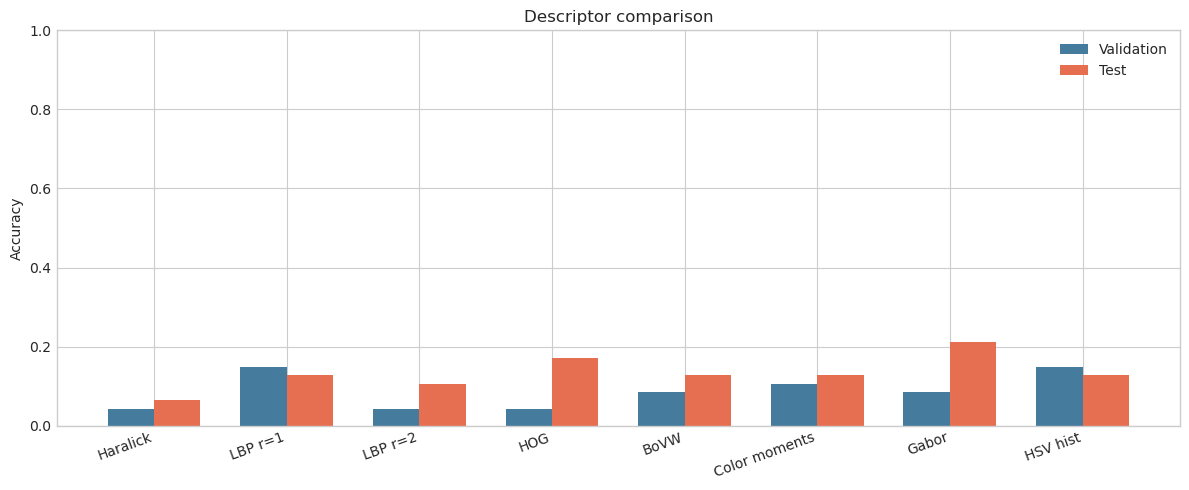

In [45]:
# Compare validation and test accuracy for each descriptor.
labels = list(results)
validation_scores = [results[label]['validation'] for label in labels]
test_scores = [results[label]['test'] for label in labels]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, validation_scores, width, label='Validation', color='#457b9d')
ax.bar(x + width / 2, test_scores, width, label='Test', color='#e76f51')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Descriptor comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.legend()
fig.tight_layout()

## 5. Fuse the descriptors

The final step concatenates the standardized descriptor blocks and evaluates the same nearest-centroid classifier on the combined representation. This shows whether the descriptors complement each other.

In [46]:
descriptor_validation_scores = np.array([results[label]['validation'] for label in labels], dtype=np.float64)
weight_vector = descriptor_validation_scores / descriptor_validation_scores.sum() if descriptor_validation_scores.sum() > 0 else np.full(len(labels), 1.0 / len(labels))

weights = dict(zip(labels, weight_vector))
print('Descriptor weights based on validation accuracy:')
for name, weight in weights.items():
    print(f'{name}: {weight:.3f}')

weighted_train = combine_feature_blocks([block * weight for block, weight in zip(scaled_blocks['train'], weight_vector)])
weighted_validation = combine_feature_blocks([block * weight for block, weight in zip(scaled_blocks['validation'], weight_vector)])
weighted_test = combine_feature_blocks([block * weight for block, weight in zip(scaled_blocks['test'], weight_vector)])

weighted_centroids = train_nearest_centroid(weighted_train, train_labels)
weighted_validation_score = accuracy_score(validation_labels, predict_nearest_centroid(weighted_validation, weighted_centroids))
weighted_test_score = accuracy_score(test_labels, predict_nearest_centroid(weighted_test, weighted_centroids))

print(f'Weighted validation accuracy: {weighted_validation_score:.3f}')
print(f'Weighted test accuracy: {weighted_test_score:.3f}')

Descriptor weights based on validation accuracy:
Haralick: 0.061
LBP r=1: 0.212
LBP r=2: 0.061
HOG: 0.061
BoVW: 0.121
Color moments: 0.152
Gabor: 0.121
HSV hist: 0.212
Weighted validation accuracy: 0.170
Weighted test accuracy: 0.149


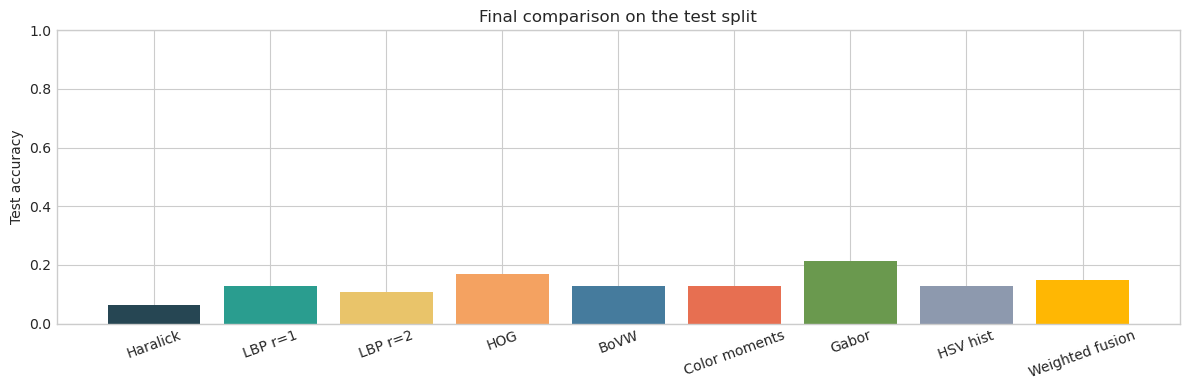

In [47]:
# Visual summary of the pipeline performance.
summary_labels = labels + ['Weighted fusion']
summary_scores = test_scores + [weighted_test_score]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(summary_labels, summary_scores, color=['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#457b9d', '#e76f51', '#6a994e', '#8d99ae', '#ffb703'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test accuracy')
ax.set_title('Final comparison on the test split')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()

## Notes

- The notebook mirrors the pipeline in `project.py`.
- Haralick, both LBP scales, HOG, and BoVW are based on the methods in `descritores_02.html`.
- Color moments, Gabor, and HSV histograms add complementary low-cost cues without changing the classifier.
- The simple nearest-centroid classifier keeps the notebook self-contained and easy to inspect.
- The final fusion is weighted by validation accuracy, so stronger descriptors contribute more.
- The BoVW codebook is searched over several cluster counts and the best one is kept automatically.

## 6. Rerun on well-sampled classes

To check whether the previous results were hurt by class imbalance, rerun the whole pipeline on only the classes that had more than 10 training samples in the original split.

In [48]:
selected_classes = [class_name for class_name, count in Counter(record.class_name for record in train_records).items() if count > 10]
subset_records = [record for record in records if record.class_name in selected_classes]

print(f'Selected classes: {len(selected_classes)}')
print(', '.join(sorted(selected_classes)))
print(f'Subset images: {len(subset_records)}')

subset_train_records, subset_test_records, subset_validation_records, subset_skipped = split_pets_by_class(subset_records)
print(f'Subset train: {len(subset_train_records)}')
print(f'Subset validation: {len(subset_validation_records)}')
print(f'Subset test: {len(subset_test_records)}')

subset_bovw_runs = []
subset_best_bovw = None

for cluster_count in BOVW_CLUSTER_CANDIDATES:
    subset_codebook = build_bovw_codebook(
        subset_train_records,
        region_size=BOVW_REGION_SIZE,
        clusters=cluster_count,
        points=BOVW_POINTS,
        radius=BOVW_RADIUS,
    )
    print(f'Subset BoVW codebook size ({cluster_count} clusters): {len(subset_codebook)}')

    subset_train_labels, subset_train_bundles = extract_bundles(
        subset_train_records,
        subset_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    subset_validation_labels, subset_validation_bundles = extract_bundles(
        subset_validation_records,
        subset_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )
    subset_test_labels, subset_test_bundles = extract_bundles(
        subset_test_records,
        subset_codebook,
        haralick_levels=HARALICK_LEVELS,
        lbp_points=LBP_POINTS,
        lbp_radius_r1=LBP_RADIUS_R1,
        lbp_radius_r2=LBP_RADIUS_R2,
        hog_bins=HOG_BINS,
        bovw_region_size=BOVW_REGION_SIZE,
        bovw_points=BOVW_POINTS,
        bovw_radius=BOVW_RADIUS,
        gabor_frequencies=GABOR_FREQUENCIES,
        gabor_orientations=GABOR_ORIENTATIONS,
        gabor_sigma=GABOR_SIGMA,
        gabor_gamma=GABOR_GAMMA,
        hsv_bins=HSV_BINS,
    )

    subset_train_matrix = matrix_from_bundles(subset_train_bundles, 'bovw')
    subset_validation_matrix = matrix_from_bundles(subset_validation_bundles, 'bovw')
    subset_test_matrix = matrix_from_bundles(subset_test_bundles, 'bovw')

    subset_train_scaled, subset_mean, subset_std = standardize_features(subset_train_matrix)
    subset_validation_scaled = apply_standardization(subset_validation_matrix, subset_mean, subset_std)
    subset_test_scaled = apply_standardization(subset_test_matrix, subset_mean, subset_std)

    subset_centroids = train_nearest_centroid(subset_train_scaled, subset_train_labels)
    subset_validation_score = accuracy_score(subset_validation_labels, predict_nearest_centroid(subset_validation_scaled, subset_centroids))
    subset_test_score = accuracy_score(subset_test_labels, predict_nearest_centroid(subset_test_scaled, subset_centroids))

    subset_bovw_runs.append({
        'clusters': cluster_count,
        'codebook': subset_codebook,
        'train_labels': subset_train_labels,
        'train_bundles': subset_train_bundles,
        'validation_labels': subset_validation_labels,
        'validation_bundles': subset_validation_bundles,
        'test_labels': subset_test_labels,
        'test_bundles': subset_test_bundles,
        'validation_score': subset_validation_score,
        'test_score': subset_test_score,
    })

    if subset_best_bovw is None or subset_validation_score > subset_best_bovw['validation_score']:
        subset_best_bovw = subset_bovw_runs[-1]

assert subset_best_bovw is not None
print(f"Subset best BoVW clusters by validation: {subset_best_bovw['clusters']}")
print(f"Subset best BoVW validation accuracy: {subset_best_bovw['validation_score']:.3f}")
print(f"Subset best BoVW test accuracy: {subset_best_bovw['test_score']:.3f}")

subset_bovw_codebook = subset_best_bovw['codebook']
subset_train_labels = subset_best_bovw['train_labels']
subset_train_bundles = subset_best_bovw['train_bundles']
subset_validation_labels = subset_best_bovw['validation_labels']
subset_validation_bundles = subset_best_bovw['validation_bundles']
subset_test_labels = subset_best_bovw['test_labels']
subset_test_bundles = subset_best_bovw['test_bundles']

subset_descriptor_names = descriptor_names
subset_results = {}
subset_scaled_blocks = {'train': [], 'validation': [], 'test': []}

for descriptor_name in subset_descriptor_names:
    subset_train_matrix = matrix_from_bundles(subset_train_bundles, descriptor_name)
    subset_validation_matrix = matrix_from_bundles(subset_validation_bundles, descriptor_name)
    subset_test_matrix = matrix_from_bundles(subset_test_bundles, descriptor_name)

    subset_train_scaled, subset_mean, subset_std = standardize_features(subset_train_matrix)
    subset_validation_scaled = apply_standardization(subset_validation_matrix, subset_mean, subset_std)
    subset_test_scaled = apply_standardization(subset_test_matrix, subset_mean, subset_std)

    subset_centroids = train_nearest_centroid(subset_train_scaled, subset_train_labels)
    subset_validation_score = accuracy_score(subset_validation_labels, predict_nearest_centroid(subset_validation_scaled, subset_centroids))
    subset_test_score = accuracy_score(subset_test_labels, predict_nearest_centroid(subset_test_scaled, subset_centroids))

    subset_results[descriptor_labels[descriptor_name]] = {
        'test': subset_test_score,
        'validation': subset_validation_score,
    }
    subset_scaled_blocks['train'].append(subset_train_scaled)
    subset_scaled_blocks['validation'].append(subset_validation_scaled)
    subset_scaled_blocks['test'].append(subset_test_scaled)

subset_validation_scores = np.array([subset_results[label]['validation'] for label in list(subset_results)], dtype=np.float64)
subset_weight_vector = subset_validation_scores / subset_validation_scores.sum() if subset_validation_scores.sum() > 0 else np.full(len(subset_results), 1.0 / len(subset_results))

subset_weighted_train = combine_feature_blocks([block * weight for block, weight in zip(subset_scaled_blocks['train'], subset_weight_vector)])
subset_weighted_validation = combine_feature_blocks([block * weight for block, weight in zip(subset_scaled_blocks['validation'], subset_weight_vector)])
subset_weighted_test = combine_feature_blocks([block * weight for block, weight in zip(subset_scaled_blocks['test'], subset_weight_vector)])

subset_weighted_centroids = train_nearest_centroid(subset_weighted_train, subset_train_labels)
subset_weighted_validation_score = accuracy_score(subset_validation_labels, predict_nearest_centroid(subset_weighted_validation, subset_weighted_centroids))
subset_weighted_test_score = accuracy_score(subset_test_labels, predict_nearest_centroid(subset_weighted_test, subset_weighted_centroids))

print('Subset descriptor weights:')
for name, weight in zip(subset_results, subset_weight_vector):
    print(f'{name}: {weight:.3f}')

print(f'Subset weighted validation accuracy: {subset_weighted_validation_score:.3f}')
print(f'Subset weighted test accuracy: {subset_weighted_test_score:.3f}')

Selected classes: 12
billy_franzen, daisy, de_victor, emilia, hamtaro, kefka, kyara, lulu, luna, milka, spike, zed
Subset images: 192
Subset train: 150
Subset validation: 21
Subset test: 21
Subset BoVW codebook size (4 clusters): 4
Subset BoVW codebook size (8 clusters): 8
Subset BoVW codebook size (12 clusters): 12
Subset BoVW codebook size (16 clusters): 16
Subset best BoVW clusters by validation: 8
Subset best BoVW validation accuracy: 0.238
Subset best BoVW test accuracy: 0.190
Subset descriptor weights:
Haralick: 0.021
LBP r=1: 0.125
LBP r=2: 0.125
HOG: 0.104
BoVW: 0.104
Color moments: 0.208
Gabor: 0.146
HSV hist: 0.167
Subset weighted validation accuracy: 0.381
Subset weighted test accuracy: 0.190


## 7. Visualize the well-sampled subset

The rerun on classes with more than 10 training samples should be read the same way as the full pipeline: first compare the descriptors, then check whether the weighted fusion improves the final result.

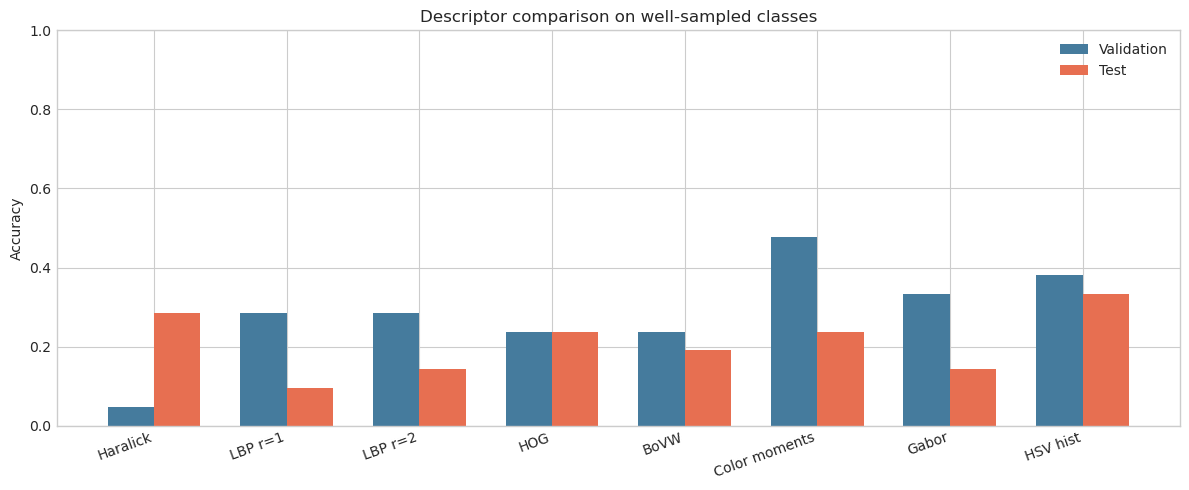

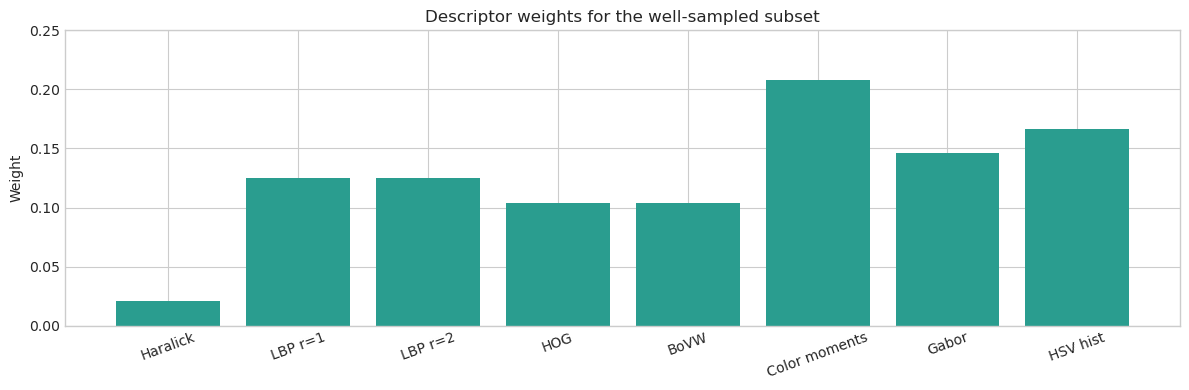

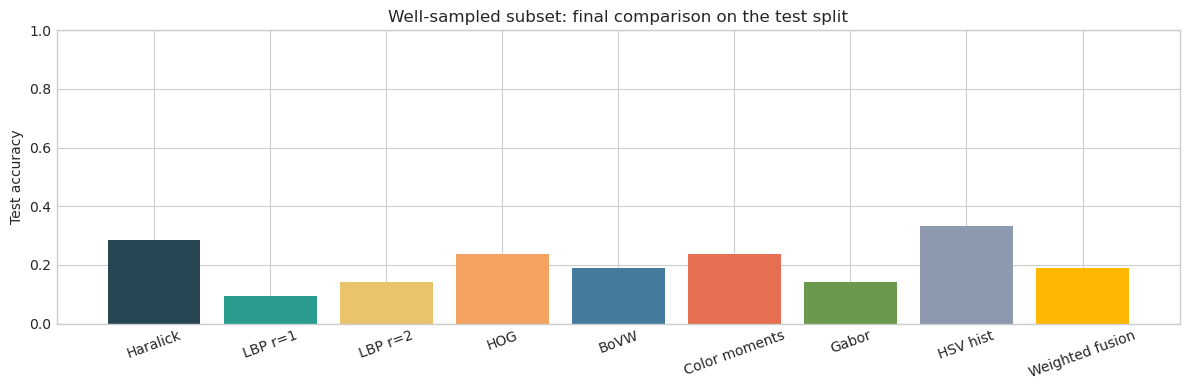

In [49]:
subset_labels = list(subset_results)
subset_validation_scores = [subset_results[label]['validation'] for label in subset_labels]
subset_test_scores = [subset_results[label]['test'] for label in subset_labels]
subset_x = np.arange(len(subset_labels))
subset_width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(subset_x - subset_width / 2, subset_validation_scores, subset_width, label='Validation', color='#457b9d')
ax.bar(subset_x + subset_width / 2, subset_test_scores, subset_width, label='Test', color='#e76f51')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Descriptor comparison on well-sampled classes')
ax.set_xticks(subset_x)
ax.set_xticklabels(subset_labels, rotation=20, ha='right')
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(subset_labels, subset_weight_vector, color='#2a9d8f')
ax.set_ylim(0, max(subset_weight_vector) * 1.2 if len(subset_weight_vector) else 1)
ax.set_ylabel('Weight')
ax.set_title('Descriptor weights for the well-sampled subset')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()

subset_summary_labels = subset_labels + ['Weighted fusion']
subset_summary_scores = subset_test_scores + [subset_weighted_test_score]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(subset_summary_labels, subset_summary_scores, color=['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#457b9d', '#e76f51', '#6a994e', '#8d99ae', '#ffb703'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test accuracy')
ax.set_title('Well-sampled subset: final comparison on the test split')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()